# Phase 5c: Growth Trend Proxy

Estimates whether each business's customer attention is growing or
shrinking over time, using review volume as the observable signal.

**This is a proxy, not real revenue growth.** This dataset has no
financial, foot-traffic, or transaction data at all. `growth_proxy_review_volume_trend`
measures whether a business's *review volume* is trending up or down over
time — a stand-in for demand/attention growth, not actual revenue. Review
volume can rise or fall for reasons unrelated to business health (a viral
post, Yelp's own recommendation algorithm, a single busy event) — this
must be named as a proxy throughout, never presented as measured growth.

**Design decided in advance** (see `docs/capstone-plan-of-action.md` Phase
5c for the full reasoning): the trend is the slope of a linear regression
of monthly review count against time, computed only for businesses with
**at least 6 distinct active months** of review history — below that, a
monthly trend is fit through too few points to mean anything. Businesses
under the threshold get `NaN`, not a fabricated number, plus a companion
column recording why. No secondary total-review-count floor. Even at 6
points, a fitted slope is a coarse estimate — that caveat must appear in
the Phase 7 write-up.

**Independent of Phase 5a and 5b** — uses `reviews_with_sentiment.csv`
directly, not `business_features.csv`, `business_segments.csv`, or
`risk_proxy_closed`.

## Load reviews and aggregate to monthly counts per business

Each row becomes (business_id, calendar month, review count that month) —
the actual time series the trend regression will be fit on.

In [1]:
import pandas as pd

reviews = pd.read_csv('../data/reviews_with_sentiment.csv', parse_dates=['date'])
reviews['year_month'] = reviews['date'].dt.to_period('M')

monthly_counts = (
    reviews.groupby(['business_id', 'year_month'])
    .size()
    .reset_index(name='review_count')
)

monthly_counts.shape

(404424, 3)

## Compute active months per business

This drives the 6-month eligibility threshold. `monthly_counts` above only
contains rows where a business actually got ≥1 review that month (a
`groupby().size()` never produces zero-count rows), so counting distinct
`year_month` values per business here directly gives the "active months"
count agreed on in the design.

In [2]:
active_months = monthly_counts.groupby('business_id')['year_month'].nunique().rename('growth_proxy_active_months')

MIN_ACTIVE_MONTHS = 6
eligible_business_ids = active_months[active_months >= MIN_ACTIVE_MONTHS].index

print(f'{len(active_months):,} total businesses')
print(f'{len(eligible_business_ids):,} eligible (>= {MIN_ACTIVE_MONTHS} active months, {len(eligible_business_ids) / len(active_months):.1%})')
print(f'{len(active_months) - len(eligible_business_ids):,} excluded (get NaN)')

14,560 total businesses
12,904 eligible (>= 6 active months, 88.6%)
1,656 excluded (get NaN)


## Fit the trend slope

**Important subtlety**: `monthly_counts` only has rows for months with
≥1 review — it's missing zero-review months entirely. Fitting a
regression directly on that sparse table would silently skip gaps (e.g. a
business with reviews in Jan, Feb, then nothing until Nov would look like
consecutive months to the regression, badly distorting the slope). So for
each eligible business, we first build a **complete monthly calendar**
from its first to last review month — filling gap months with 0 — and
regress against that. This is a different (and more correct) grid than the
"active months" count above, which deliberately only counts non-zero
months for the eligibility threshold; the dense grid below is only for
computing the slope itself.

`scipy.stats.linregress` gives the slope directly; x is a simple 0, 1, 2...
month index (not calendar dates) so the slope is naturally in "reviews per
month" units.

In [3]:
import numpy as np
from scipy.stats import linregress

monthly_counts_indexed = monthly_counts.set_index(['business_id', 'year_month'])['review_count']

slopes = {}
for i, business_id in enumerate(eligible_business_ids):
    biz_counts = monthly_counts_indexed.loc[business_id]
    full_range = pd.period_range(biz_counts.index.min(), biz_counts.index.max(), freq='M')
    dense = biz_counts.reindex(full_range, fill_value=0)

    x = np.arange(len(dense))
    y = dense.values
    slope, *_ = linregress(x, y)
    slopes[business_id] = slope

    if (i + 1) % 2000 == 0:
        print(f'{i + 1:,} / {len(eligible_business_ids):,} businesses processed...')

growth_trend = pd.Series(slopes, name='growth_proxy_review_volume_trend')
growth_trend.describe()

2,000 / 12,904 businesses processed...


4,000 / 12,904 businesses processed...


6,000 / 12,904 businesses processed...


8,000 / 12,904 businesses processed...


10,000 / 12,904 businesses processed...


12,000 / 12,904 businesses processed...


count    12904.000000
mean        -0.022744
std          0.106618
min         -2.321429
25%         -0.008314
50%         -0.000482
75%          0.001675
max          0.314286
Name: growth_proxy_review_volume_trend, dtype: float64

## Sanity-check by hand

Per the plan doc's own checklist ("sanity-check outputs on a handful of
rows by hand"): pick the business with the steepest rising trend, the
steepest falling trend, and one near zero, and actually look at their
monthly review counts plotted against the fitted line — confirming the
slope matches what the eyeball test says, not just trusting the number.

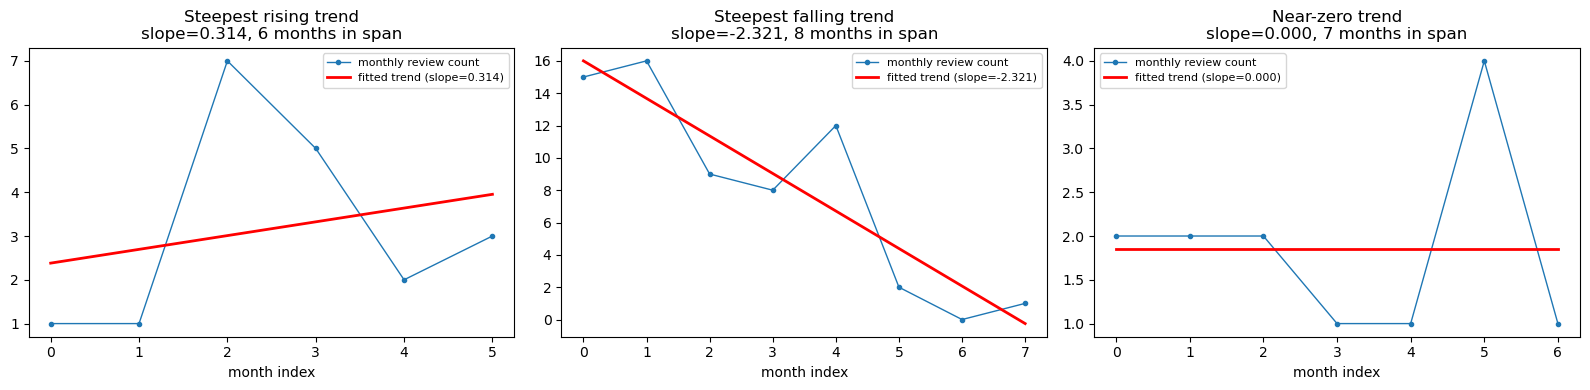

In [4]:
import matplotlib.pyplot as plt

def plot_business_trend(business_id, ax, label):
    biz_counts = monthly_counts_indexed.loc[business_id]
    full_range = pd.period_range(biz_counts.index.min(), biz_counts.index.max(), freq='M')
    dense = biz_counts.reindex(full_range, fill_value=0)
    x = np.arange(len(dense))

    slope, intercept, *_ = linregress(x, dense.values)
    ax.plot(x, dense.values, marker='o', markersize=3, linewidth=1, label='monthly review count')
    ax.plot(x, intercept + slope * x, color='red', linewidth=2, label=f'fitted trend (slope={slope:.3f})')
    ax.set_title(f'{label}\nslope={slope:.3f}, {len(dense)} months in span')
    ax.set_xlabel('month index')
    ax.legend(fontsize=8)

steepest_up = growth_trend.idxmax()
steepest_down = growth_trend.idxmin()
near_zero = (growth_trend - 0).abs().idxmin()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_business_trend(steepest_up, axes[0], 'Steepest rising trend')
plot_business_trend(steepest_down, axes[1], 'Steepest falling trend')
plot_business_trend(near_zero, axes[2], 'Near-zero trend')
plt.tight_layout()
plt.show()

## Save output

Saved as a **separate file**, same reasoning as Phase 5a's segments —
keeps the three Phase 5 tasks independent rather than making them all
implicitly depend on this notebook having run.

Businesses below the 6-month threshold get `NaN` for the trend but are
still included in the file (with their `growth_proxy_active_months` value
visible) — not silently dropped, so anyone using this file can see exactly
which businesses have no reliable trend estimate and why.

In [5]:
growth_output = active_months.to_frame().join(growth_trend).reset_index()

growth_output.to_csv('../data/business_growth_trend.csv', index=False)

print(f'{len(growth_output):,} businesses, {growth_output["growth_proxy_review_volume_trend"].notna().sum():,} with a valid trend')
growth_output.head()

14,560 businesses, 12,904 with a valid trend


,business_id,growth_proxy_active_months,growth_proxy_review_volume_trend
0,--OS_I7dnABrXvRCCuWOGQ,5,NaN
1,--sXnWH9Xm6_NvIjyuA99w,22,0.002018
2,-0M0b-XhtFagyLmsBtOe8w,13,-0.007929
3,-0PN_KFPtbnLQZEeb23XiA,11,-0.001315
4,-0TffRSXXIlBYVbb5AwfTg,104,-0.044361
